In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy
import pandas as pd
from scipy.stats import norm
import corner

In [2]:
import dynesty

from dynesty import utils as dyfunc
from dynesty import plotting as dyplot

In [3]:
path = '../solutions/transient.npy'

In [4]:
data = np.load(path)
np.shape(data)
times = []
F = []
sF = []
for i in range(100):
    times = np.append(times,data[i][0])
    F = np.append(F,data[i][1])
    sF = np.append(sF,data[i][2])

In [5]:
def burst(theta,t):
    A,b,t0,alpha=theta 
    return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))

def gprofile(theta,t):
    A,b,t0,sigmaW=theta     
    return b+A*np.exp(-(((t-t0)/sigmaW)**2 ) / 2)

In [6]:
t0min,t0max = 0,100
Amin,Amax=0,50
bmin,bmax=0,50
alphamin,alphamax=np.exp(-5),np.exp(5)

sigmaWmin,sigmaWmax=np.exp(-2),np.exp(2)

In [7]:
def loglike(theta, data, model):
    x, y, sigma_y = data.T
    if model =='burst':
        y_fit = burst(theta, x)
    elif model == 'gprofile':
        y_fit = gprofile(theta, x)
        
    return -0.5 * np.sum((y-y_fit)**2 / sigma_y**2 ) 


def ptform(u,model):
    x = np.array(u)  # copy u

    x[0] = scipy.stats.uniform(loc=Amin,scale=Amax-Amin).ppf(u[0])
    x[1] = scipy.stats.uniform(loc=bmin,scale=bmax-bmin).ppf(u[1])
    x[2] = scipy.stats.uniform(loc=t0min,scale=t0max-t0min).ppf(u[2])
   
    if model =='burst':
        x[3] = scipy.stats.loguniform.ppf(u[3],alphamin,alphamax)
    elif model =='gprofile':
        x[3] = scipy.stats.loguniform.ppf(u[3],sigmaWmin,sigmaWmax)
    return x

In [8]:
ndim = 4

In [9]:
import warnings

# Burst model

In [28]:
with warnings.catch_warnings():
    # Those warnings come from regions where the likelihood is ~zero
    warnings.simplefilter("ignore", category=RuntimeWarning)

    # Define and run sampler
    sampler = dynesty.NestedSampler(loglike, ptform, ndim,logl_args=[data,'burst'],ptform_args=['burst'],nlive=300)
    sampler.run_nested()
    sresults = sampler.results

2356it [01:43,  2.99it/s, bound: 111 | nc: 96 | ncall: 55300 | eff(%):  4.260 | loglstar:   -inf < -86.406 <    inf | logz: -93.242 +/-  0.137 | dlogz: 34.751 >  0.309] /home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
4698it [02:47, 28.08it/s, +300 | bound: 195 | nc: 1 | ncall: 88551 | eff(%):  5.663 | loglstar:   -inf < -48.777 <    inf | logz: -63.160 +/-  0.212 | dlogz:  0.001 >  0.309]


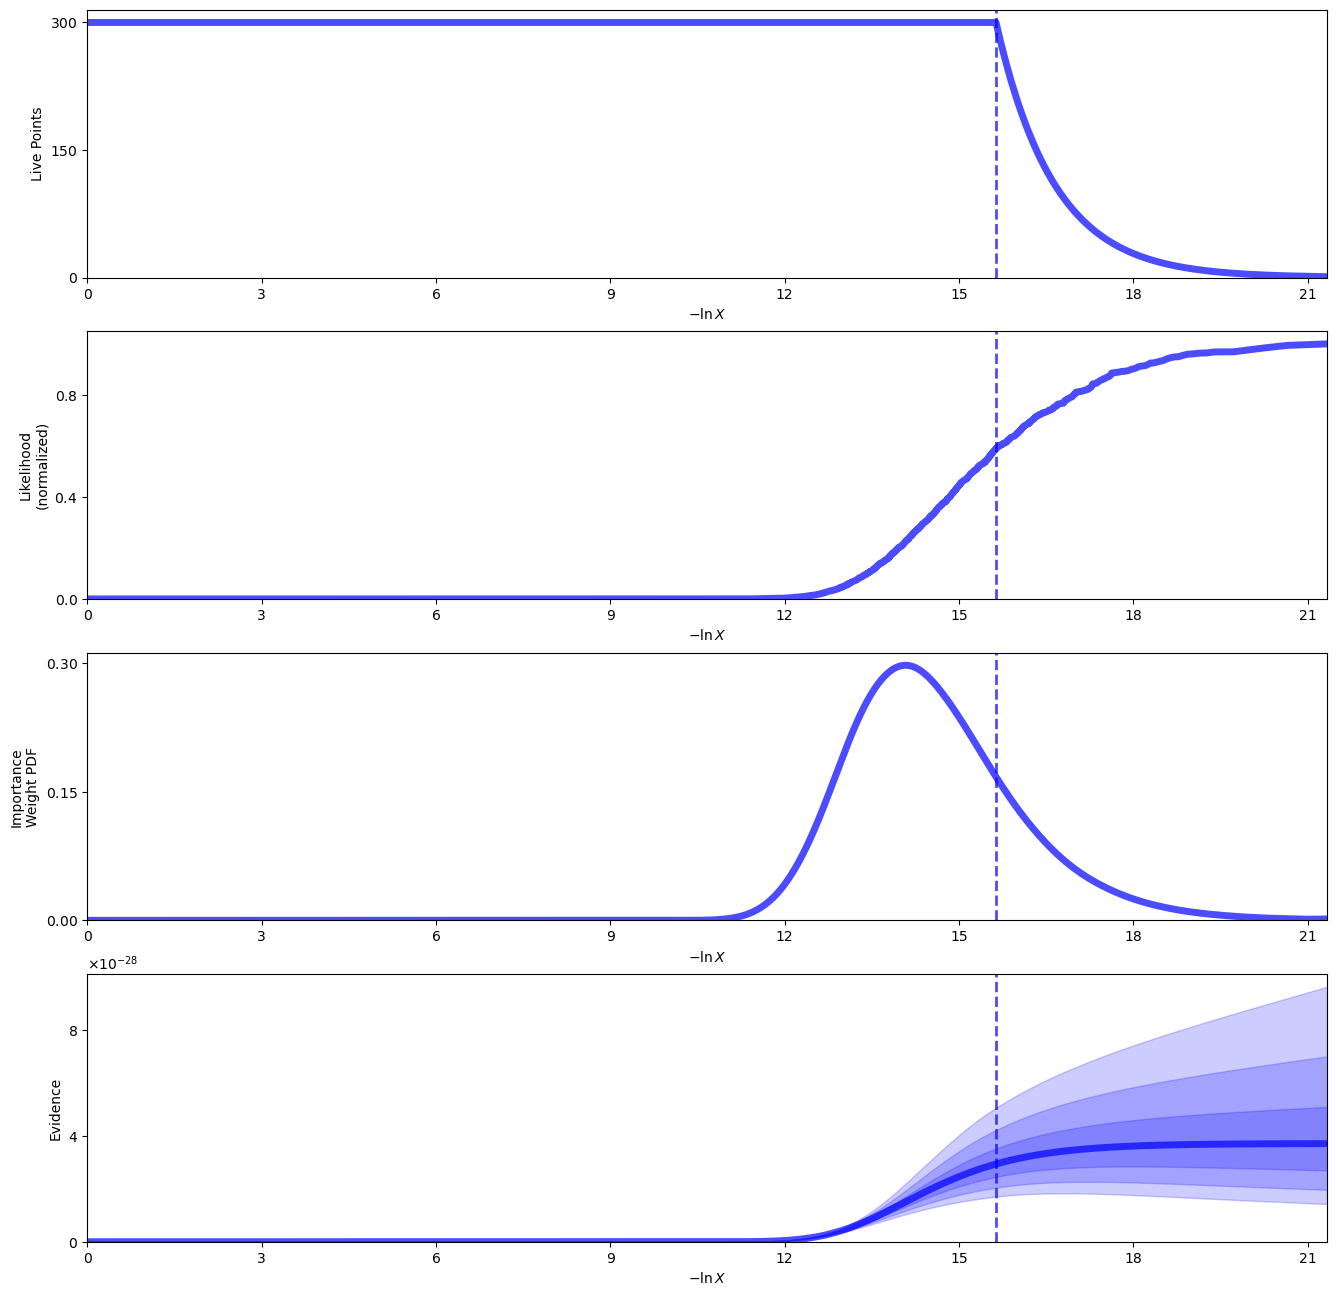

In [29]:
rfig, raxes = dyplot.runplot(sresults)

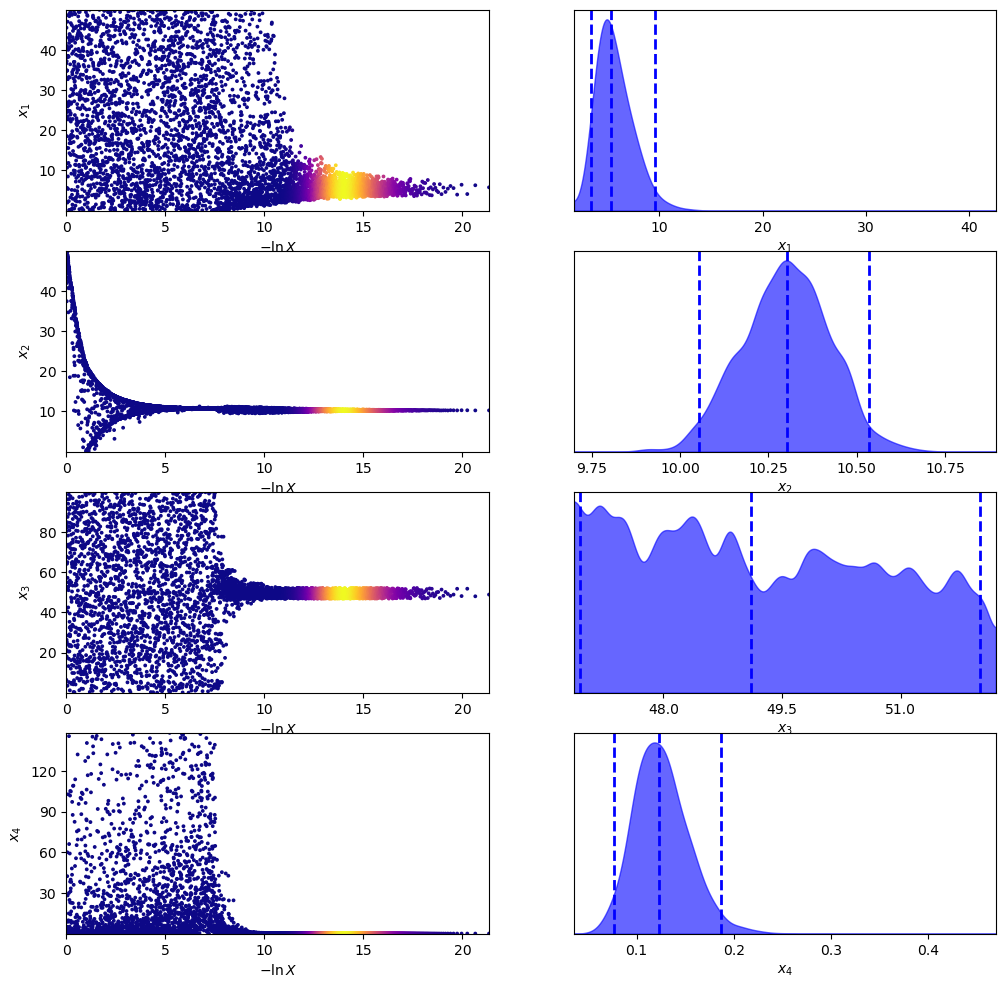

In [30]:
tfig, taxes = dyplot.traceplot(sresults)

In [31]:
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

evidence = sresults.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))


Bayesian evidence 3.7131618777807364e-28
68% parameter credible regions are:
 [[4.1446579864080455, 7.391430562675745], [10.169739938754368, 10.42355846649445], [47.49880507502225, 51.10792112388083], [0.09901008513485124, 0.15335672027240657]]

Mean and covariance of parameters are: [ 5.70238674 10.29971535 49.27357208  0.12558874]
[[ 2.77086607e+00  2.20217244e-02 -1.72395936e+00  2.70732877e-02]
 [ 2.20217244e-02  1.52883450e-02 -8.38379204e-03  1.38895896e-03]
 [-1.72395936e+00 -8.38379204e-03  2.35411343e+00 -1.12959793e-03]
 [ 2.70732877e-02  1.38895896e-03 -1.12959793e-03  7.80618000e-04]]


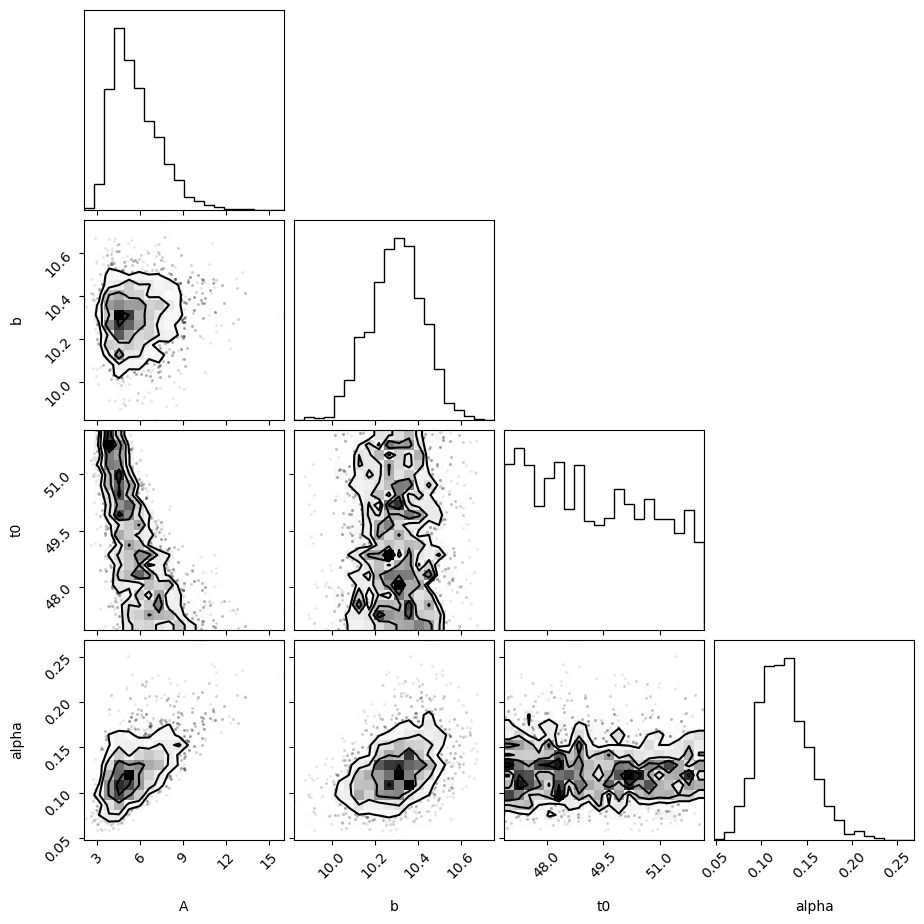

In [32]:
labels = ["A","b","t0","alpha"]

samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal,labels=labels);

In [33]:
quantiles = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights)
             for samps in samples.T]
for q,l in zip(quantiles,labels):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

A   5.369922817215637 +3.4634251003742316 -1.7685604165783815
b   10.301415315633369 +0.18881935183933685 -0.20795302820320138
t0   49.10686813271286 +2.694269141429963 -2.049977310604916
alpha   0.1231259885410549 +0.05190024301393138 -0.0379958889659016


In [36]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = dyfunc.quantile(samples[:,i], [0.05, 0.5, 0.95], weights=weights)
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [37]:
sresults.summary()

Summary
nlive: 300
niter: 4698
ncall: 88251
eff(%):  5.663
logz: -63.160 +/-  0.319


# Gaussian

In [17]:
with warnings.catch_warnings():
    # Those warnings come from regions where the likelihood is ~zero
    warnings.simplefilter("ignore", category=RuntimeWarning)
    
    sampler = dynesty.NestedSampler(loglike, ptform, ndim,logl_args=[data,'gprofile'],ptform_args=['gprofile'],nlive=300)
    sampler.run_nested()
    sresults2 = sampler.results

2422it [02:17,  3.62it/s, bound: 108 | nc: 139 | ncall: 56169 | eff(%):  4.312 | loglstar:   -inf < -86.741 <    inf | logz: -94.384 +/-  0.149 | dlogz: 31.016 >  0.309]/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
2423it [02:17,  3.08it/s, bound: 109 | nc: 183 | ncall: 56352 | eff(%):  4.300 | loglstar:   -inf < -86.718 <    inf | logz: -94.382 +/-  0.149 | dlogz: 31.010 >  0.309]/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstr

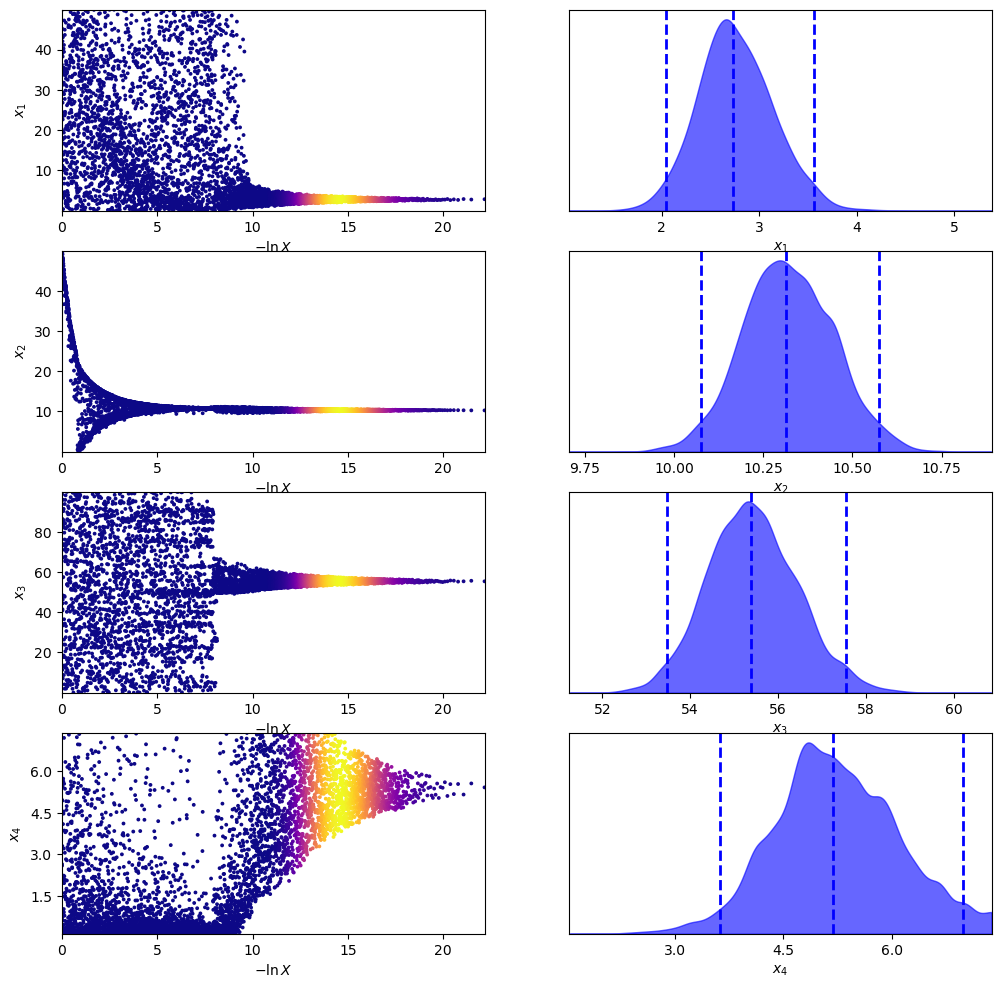

In [18]:
tfig, taxes = dyplot.traceplot(sresults2)

In [38]:
samples2 = sresults2.samples  # samples
weights2 = np.exp(sresults2.logwt - sresults2.logz[-1])  # normalized weights

evidence2 = sresults2.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence2))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights2)
             for samps in samples2.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples2, weights2)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))


Bayesian evidence 3.916234861570783e-30
68% parameter credible regions are:
 [[2.3884302957160695, 3.1366435527112806], [10.197453346316184, 10.44699509484265], [54.42269710277237, 56.43800814699593], [4.388261380036864, 6.062951638621466]]

Mean and covariance of parameters are: [ 2.76039738 10.3199125  55.41617171  5.22612883]
[[ 0.14577963 -0.01015343 -0.12428196 -0.12632553]
 [-0.01015343  0.01576377 -0.02074194 -0.04129288]
 [-0.12428196 -0.02074194  1.03645084  0.31932858]
 [-0.12632553 -0.04129288  0.31932858  0.72149439]]


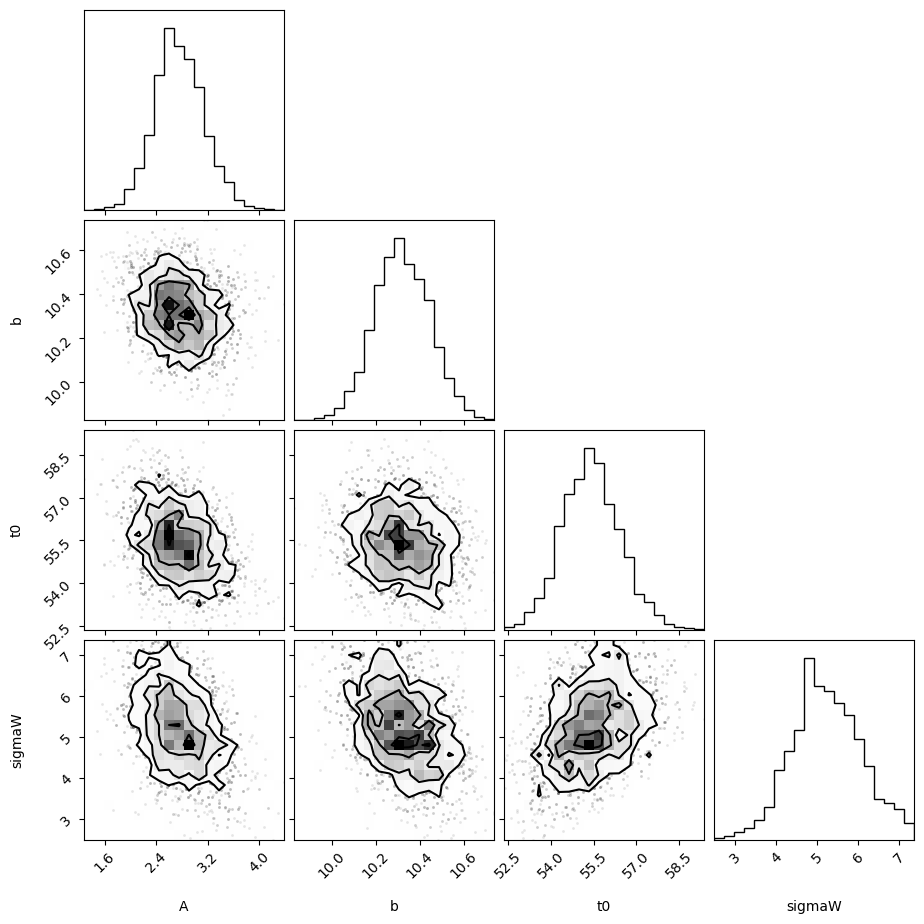

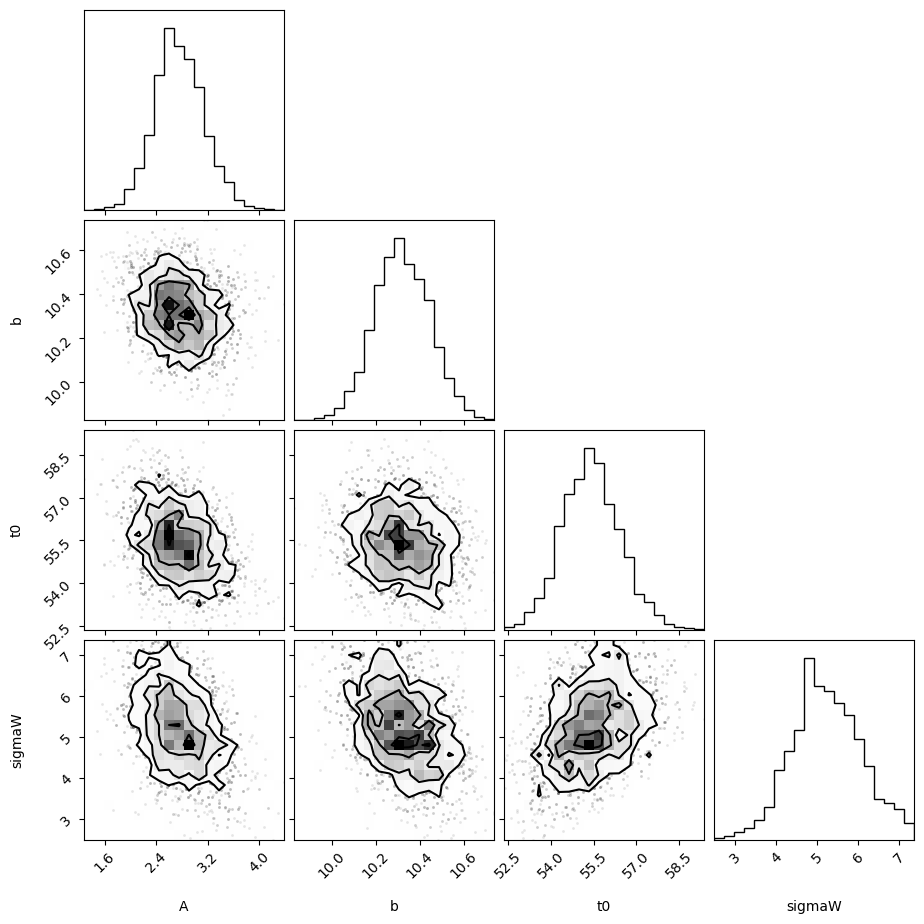

In [39]:
labels = ["A","b","t0","sigmaW"]

samples2_equal = dyfunc.resample_equal(samples2, weights2)
corner.corner(samples2_equal,labels=labels)

In [40]:
for i in range(ndim):
    mcmc = dyfunc.quantile(samples2[:,i], [0.05, 0.5, 0.95], weights=weights2)
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [41]:
sresults2.summary()

Summary
nlive: 300
niter: 4946
ncall: 162090
eff(%):  3.236
logz: -67.712 +/-  0.324


In [42]:
# Final Comparison
# odds ratio between Burst and Gaussian --> the burst model is strongly favoured
np.exp(sresults.logz[-1])/np.exp(sresults2.logz[-1])

94.81458617860842